The baseline QWEN model on Spider text-to-sql. No finetuning is applied here

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
from google.colab import userdata
from urllib.parse import quote
import os
import shutil
import subprocess

token = userdata.get("GITLAB_TOKEN")

if not token:
    raise ValueError(
        "GITLAB_TOKEN is missing or notebook access is disabled."
    )

encoded_token = quote(token.strip(), safe="")

repo_url = (
    f"https://oauth2:{encoded_token}"
    "@git.cs.bham.ac.uk/txh517/msc_project.git"
)

destination = "/content/msc_project"
shutil.rmtree(destination, ignore_errors=True)

result = subprocess.run(
    ["git", "clone", repo_url, destination],
    text=True,
    capture_output=True,
)

print(result.stdout)
print(result.stderr.replace(encoded_token, "****"))

if result.returncode != 0:
    raise RuntimeError("Clone failed. Check the error above.")

os.chdir(destination)

# Remove the embedded token from the stored remote URL.
subprocess.run(
    [
        "git",
        "remote",
        "set-url",
        "origin",
        "https://git.cs.bham.ac.uk/txh517/msc_project.git",
    ],
    check=True,
)

print("Current directory:", os.getcwd())


Cloning into '/content/msc_project'...

Current directory: /content/msc_project


In [ ]:
%cd /content/msc_project
%pip install -q -e .

/content
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 863.2/863.2 kB 69.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 52.7 MB/s eta 0:00:00
  Building editable for slm-text-to-sql (pyproject.toml) ... done


In [ ]:
from pathlib import Path
import shutil
import zipfile

project_dir = Path("/content/msc_project")
drive_zip = Path("/content/drive/MyDrive/spider_data.zip")

extracted_source = project_dir / "data" / "spider_data"
local_spider = project_dir / "data" / "spider"
macosx = project_dir / "data" / "__MACOSX"

if not drive_zip.exists():
    raise FileNotFoundError(f"Spider ZIP not found: {drive_zip}")

# Remove any incomplete extraction from this runtime.
if extracted_source.exists():
    shutil.rmtree(extracted_source)

if local_spider.exists():
    shutil.rmtree(local_spider)

with zipfile.ZipFile(drive_zip, "r") as archive:
    archive.extractall(project_dir / "data")

if not extracted_source.exists():
    raise FileNotFoundError(
        f"Expected extracted folder not found: {extracted_source}"
    )

shutil.move(str(extracted_source), str(local_spider))

if macosx.exists():
    shutil.rmtree(macosx)

print("Spider installed at:", local_spider)

Spider installed at: /content/msc_project/data/spider


In [ ]:
from pathlib import Path
import shutil
import os

project_results = Path("/content/msc_project/baselines/results")
drive_results = Path(
    "/content/drive/MyDrive/msc_text_to_sql/results"
)

drive_results.mkdir(parents=True, exist_ok=True)

if project_results.is_symlink():
    project_results.unlink()
elif project_results.exists():
    # Preserve any local files before replacing the directory.
    for file in project_results.iterdir():
        if file.is_file():
            shutil.copy2(file, drive_results / file.name)
    shutil.rmtree(project_results)

os.symlink(drive_results, project_results)

print("Project results:", project_results)
print("Persistent target:", project_results.resolve())

Project results: /content/msc_project/baselines/results
Persistent target: /content/drive/MyDrive/msc_text_to_sql/results


In [ ]:
from pathlib import Path

config_path = Path("/content/msc_project/config.yaml")

text = config_path.read_text(encoding="utf-8")
text = text.replace("device: cpu", "device: cuda")
config_path.write_text(text, encoding="utf-8")

print(config_path.read_text())

# Global configuration. Single source of truth for anything that must be
# identical across experiments. Never hard-code these values in scripts.

seed: 42
device: cuda           # cuda | cpu

paths:
  spider_root: data/spider
  train_json: data/spider/train_spider.json
  dev_json: data/spider/dev.json
  tables_json: data/spider/tables.json
  database_dir: data/spider/database
  split_file: data/splits/train_val_split.json

models:
  slm: Qwen/Qwen2.5-Coder-3B-Instruct   # the small model (floor + all enhancements)
  llm: gpt-4o                            # the ceiling (API)

data:
  val_size: 500          # examples held out of train for hyperparameter tuning

prompt:
  schema_style: simple_ddl   # simple_ddl | verbose
  include_keys: true         # include primary/foreign keys in serialized schema

generation:
  max_new_tokens: 256
  temperature: 0.0           # greedy decoding for reproducibility



In [ ]:
from pathlib import Path
import torch
import yaml

%cd /content/msc_project

required = [
    Path("data/spider/dev.json"),
    Path("data/spider/train_spider.json"),
    Path("data/spider/tables.json"),
    Path("data/spider/database"),
]

for path in required:
    if not path.exists():
        raise FileNotFoundError(f"Missing required Spider path: {path}")
    print("OK:", path)

with open("config.yaml", "r", encoding="utf-8") as file:
    config = yaml.safe_load(file)

if config["device"] != "cuda":
    raise ValueError(
        f"config.yaml device is {config['device']!r}; expected 'cuda'."
    )

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA is unavailable. Select a GPU runtime before continuing."
    )

print("Device configuration:", config["device"])
print("GPU:", torch.cuda.get_device_name(0))
print("Checkpoint location:",
      Path("baselines/results/slm_vanilla.json").resolve())

/content
OK: data/spider/dev.json
OK: data/spider/train_spider.json
OK: data/spider/tables.json
OK: data/spider/database
Device configuration: cuda
GPU: NVIDIA A100-SXM4-40GB
Checkpoint location: /content/drive/MyDrive/msc_text_to_sql/results/slm_vanilla.json


In [ ]:
%cd /content/msc_project

!python3 -m baselines.run_slm_vanilla \
    --resume \
    --save_every 10

/content
Loading model Qwen/Qwen2.5-Coder-3B-Instruct ...
config.json: 100% 661/661 [00:00<00:00, 3.91MB/s]
tokenizer_config.json: 100% 7.30k/7.30k [00:00<00:00, 25.5MB/s]
vocab.json: 100% 2.78M/2.78M [00:00<00:00, 50.9MB/s]
merges.txt: 100% 1.67M/1.67M [00:00<00:00, 115MB/s]
tokenizer.json: 100% 7.03M/7.03M [00:00<00:00, 143MB/s]
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
model.safetensors.index.json: 100% 35.6k/35.6k [00:00<00:00, 93.3MB/s]
Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0% 0/2 [00:00<?, ?it/s]
Reconstructing (incomplete total...):   0% 0.00/1.21G [00:00<?, ?B/s]         
Reconstructing (incomplete total...):  97% 6.00G/6.17G [00:18<00:00, 274MB/s,  250MB/s  ]

Fetching 2 files: 100% 2/2 [00:18<00:00,  9.11s/it]
Download complete: 100% 5.38G/5.38G [00:18<00:00, 41.6MB/s,  176MB/s  ]
Download complete: 100% 5.38G/5.38G [00:18<00:00, 295MB/s,  176MB/s  ] 
Reconstruction complete: 100% 6.17G/6.17G

In [ ]:
import json
from pathlib import Path

results_path = Path(
    "/content/drive/MyDrive/msc_text_to_sql/results/slm_vanilla.json"
)

records = json.loads(results_path.read_text(encoding="utf-8"))
wrong = [record for record in records if not record["correct"]]

print("Total evaluated:", len(records))
print("Incorrect:", len(wrong))
print("Accuracy:", 1 - len(wrong) / len(records))

for index, record in enumerate(wrong[:], start=1):
    print(f"\n--- Error {index} ---")
    print("Database:", record["db_id"])
    print("Question:", record["question"])
    print("Predicted:", record["predicted_sql"])
    print("Gold:", record["gold_sql"])

Total evaluated: 1034
Incorrect: 387
Accuracy: 0.625725338491296

--- Error 1 ---
Database: concert_singer
Question: Show the name and the release year of the song by the youngest singer.
Predicted: SELECT T2.Name, T2.Song_release_year FROM singer AS T1 JOIN singer_in_concert AS T3 ON T1.Singer_ID = T3.Singer_ID JOIN concert AS T4 ON T3.concert_ID = T4.concert_ID JOIN song AS T2 ON T3.concert_ID = T2.concert_ID WHERE T1.Age = (SELECT MIN(Age) FROM singer)
Gold: SELECT song_name ,  song_release_year FROM singer ORDER BY age LIMIT 1

--- Error 2 ---
Database: concert_singer
Question: What are the names and release years for all the songs of the youngest singer?
Predicted: SELECT T2.Song_Name, T2.Song_release_year FROM singer AS T1 JOIN singer_in_concert AS T3 ON T1.Singer_ID = T3.Singer_ID JOIN concert AS T4 ON T3.concert_ID = T4.concert_ID JOIN song AS T2 ON T4.concert_Name = T2.concert_Name WHERE T1.Age = (SELECT MIN(Age) FROM singer)
Gold: SELECT song_name ,  song_release_year FROM si

In [ ]:
import pandas as pd

df = pd.DataFrame(records)

print(df.columns.tolist())
display(df.head())

['db_id', 'question', 'gold_sql', 'predicted_sql', 'correct', 'latency_s']


,db_id,question,gold_sql,predicted_sql,correct,latency_s
0,concert_singer,How many singers do we have?,SELECT count(*) FROM singer,SELECT COUNT(*) FROM singer,True,1.734845
1,concert_singer,What is the total number of singers?,SELECT count(*) FROM singer,SELECT COUNT(*) FROM singer,True,0.256220
2,concert_singer,"Show name, country, age for all singers ordere...","SELECT name , country , age FROM singer ORDE...","SELECT Name, Country, Age FROM singer ORDER BY...",True,0.738005
3,concert_singer,"What are the names, countries, and ages for ev...","SELECT name , country , age FROM singer ORDE...","SELECT Name, Country, Age FROM singer ORDER BY...",True,0.755230
4,concert_singer,"What is the average, minimum, and maximum age ...","SELECT avg(age) , min(age) , max(age) FROM s...","SELECT AVG(Age), MIN(Age), MAX(Age) FROM singe...",True,1.077464


In [ ]:
database_summary = (
    df.groupby("db_id")
    .agg(
        total_questions=("correct", "size"),
        correct=("correct", "sum"),
        mean_latency_s=("latency_s", "mean"),
    )
    .reset_index()
)

database_summary["incorrect"] = (
    database_summary["total_questions"] - database_summary["correct"]
)

database_summary["accuracy"] = (
    database_summary["correct"] / database_summary["total_questions"]
)

database_summary["error_rate"] = 1 - database_summary["accuracy"]

database_summary = database_summary.sort_values(
    ["error_rate", "total_questions"],
    ascending=[False, False],
)

display(database_summary.head(20))

,db_id,total_questions,correct,mean_latency_s,incorrect,accuracy,error_rate
1,car_1,92,37,1.873885,55,0.402174,0.597826
18,world_1,120,52,1.851241,68,0.433333,0.566667
13,real_estate_properties,4,2,2.023432,2,0.500000,0.500000
16,tvshow,62,32,1.371227,30,0.516129,0.483871
19,wta_1,62,32,1.314145,30,0.516129,0.483871
15,student_transcripts_tracking,78,42,1.890175,36,0.538462,0.461538
5,dog_kennels,82,45,1.734622,37,0.548780,0.451220
11,pets_1,42,25,1.995200,17,0.595238,0.404762
17,voter_1,15,9,1.865154,6,0.600000,0.400000
3,course_teach,30,19,1.361363,11,0.633333,0.366667


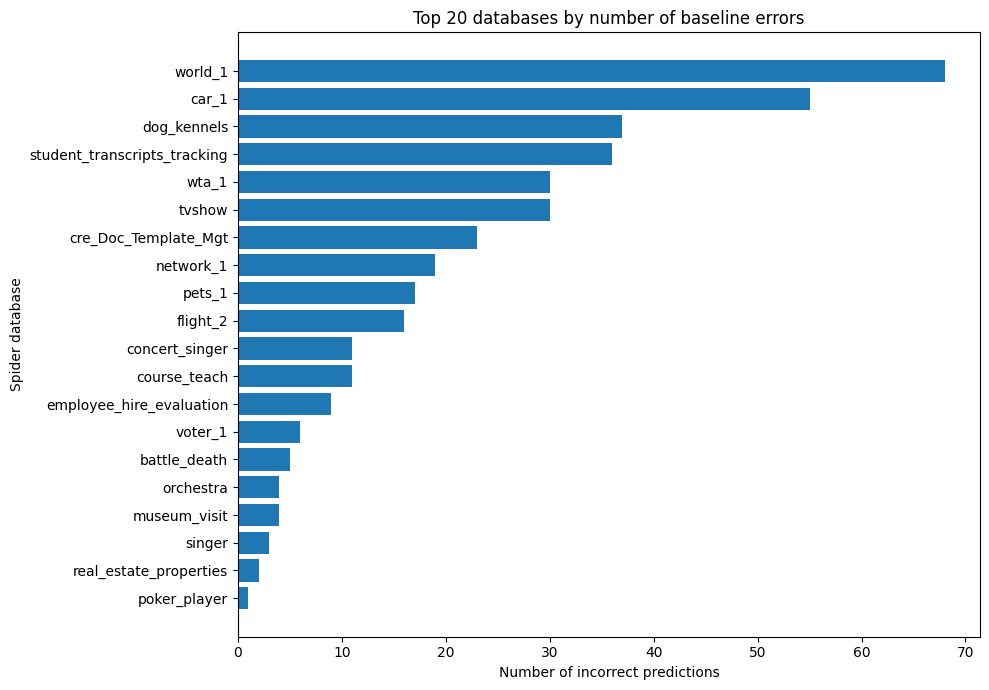

In [ ]:
import matplotlib.pyplot as plt

top_n = 20

plot_data = (
    database_summary
    .sort_values("incorrect", ascending=False)
    .head(top_n)
    .sort_values("incorrect")
)

plt.figure(figsize=(10, 7))
plt.barh(plot_data["db_id"], plot_data["incorrect"])

plt.xlabel("Number of incorrect predictions")
plt.ylabel("Spider database")
plt.title(f"Top {top_n} databases by number of baseline errors")
plt.tight_layout()
plt.show()

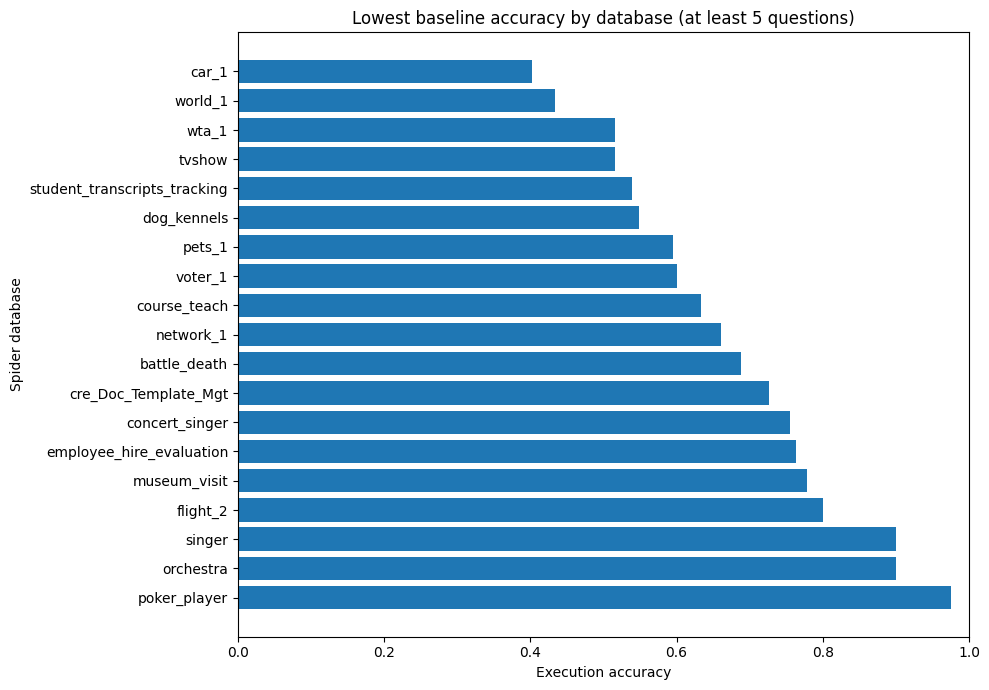

In [ ]:
minimum_questions = 5
top_n = 20

plot_data = (
    database_summary[
        database_summary["total_questions"] >= minimum_questions
    ]
    .sort_values("accuracy")
    .head(top_n)
    .sort_values("accuracy", ascending=False)
)

plt.figure(figsize=(10, 7))
plt.barh(plot_data["db_id"], plot_data["accuracy"])

plt.xlabel("Execution accuracy")
plt.ylabel("Spider database")
plt.title(
    f"Lowest baseline accuracy by database "
    f"(at least {minimum_questions} questions)"
)
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

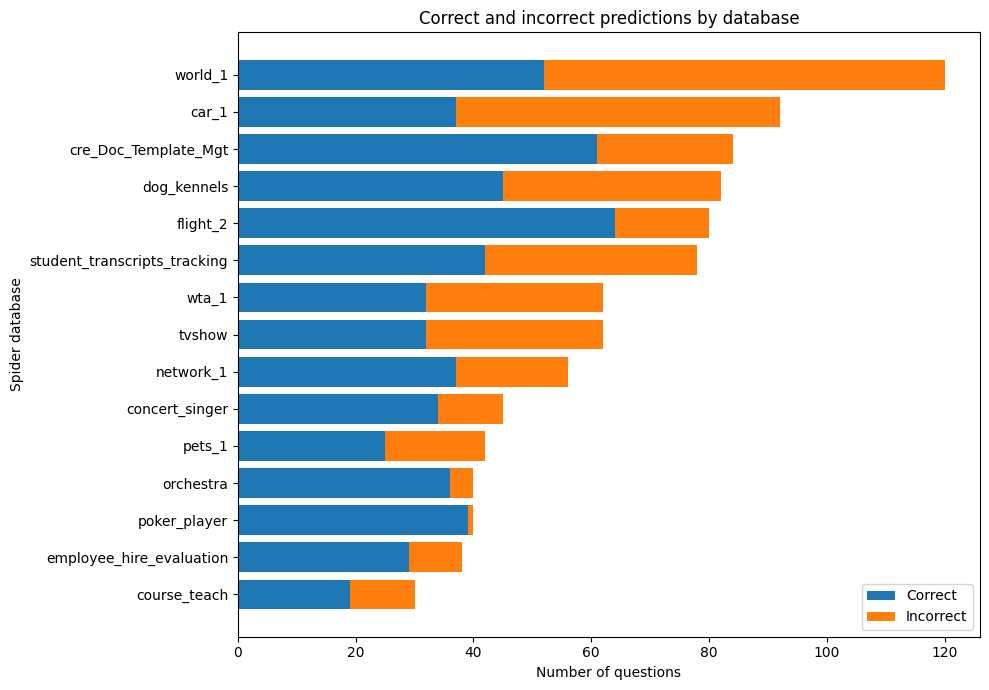

In [ ]:
top_databases = (
    database_summary
    .nlargest(15, "total_questions")
    .sort_values("total_questions")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_databases["db_id"],
    top_databases["correct"],
    label="Correct",
)

plt.barh(
    top_databases["db_id"],
    top_databases["incorrect"],
    left=top_databases["correct"],
    label="Incorrect",
)

plt.xlabel("Number of questions")
plt.ylabel("Spider database")
plt.title("Correct and incorrect predictions by database")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from pathlib import Path

for path in [
    Path("/content/drive/MyDrive/msc_text_to_sql/results/slm_vanilla.json"),
    Path("/content/drive/MyDrive/msc_text_to_sql/results/slm_vanilla_errors.csv"),
    Path("/content/drive/MyDrive/msc_text_to_sql/results/slm_vanilla_database_summary.csv"),
]:
    print(path.exists(), path)

True /content/drive/MyDrive/msc_text_to_sql/results/slm_vanilla.json
False /content/drive/MyDrive/msc_text_to_sql/results/slm_vanilla_errors.csv
False /content/drive/MyDrive/msc_text_to_sql/results/slm_vanilla_database_summary.csv
